## Equilibrating a TIP3P Water Box

Importing modules

In [3]:
import ase.units as units
from ase.build import molecule
from ase.calculators.tip3p import TIP3P
from ase.constraints import FixBondLengths
from ase.io.trajectory import Trajectory
from ase.md import Langevin

import matplotlib.pyplot as plt 
from ase.visualize.plot import plot_atoms 

Matplotlib is building the font cache; this may take a moment.


In [2]:
atoms = molecule('H2O') # creating water molecule
density = 0.9982  # denisty of water in g/cm^3 at 20°C
box_length = ((atoms.get_masses().sum() / units.mol) / (density * 1e-24)) ** (
    1 / 3
)  # box length in Å
atoms.set_cell((box_length, box_length, box_length))
atoms.center()
# Repeat the water molecule we just created to end up with a PBC cell
atoms *= (3, 3, 3)
atoms.set_pbc(True)

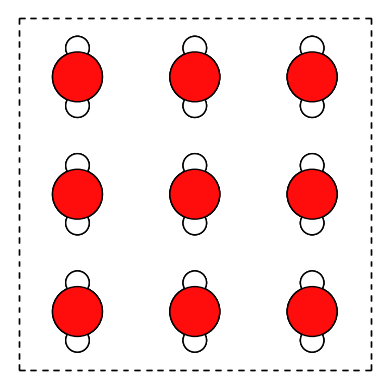

In [5]:
fig, ax = plt.subplots()
plot_atoms(atoms, ax)
ax.set_axis_off()

Contraining internel degrees of freedom. Constrain interatomic distances, O-H1, O-H2 and H1-H2 for each molecule.

In [8]:
atoms.constraints = FixBondLengths(
    [(3 * i + j, 3 * i + (j + 1) % 3) for i in range(3**3) for j in [0, 1, 2]]
)
# RATTLE-type constraints on O-H1, O-H2, H1-H2.
tag = 'tip3p_27mol_equil'
atoms.calc = TIP3P(rc=4.5)  # set the calculator to be the TIP3P force field

Equilibrate smaller box of water

In [9]:
# Equillibrate in a small box first.
md = Langevin(
    atoms,
    1 * units.fs,
    temperature_K=293.15,  # 20 °C
    friction=0.01,
    logfile=tag + '.log',
)

traj = Trajectory(tag + '.traj', 'w', atoms)
md.attach(traj.write, interval=1)
md.run(4)  # please use 4000 to better equilibrate

# Repeat box and equilibrate further.
tag = 'tip3p_216mol_equil'
atoms.set_constraint()  # repeat not compatible with FixBondLengths currently.
atoms *= (2, 2, 2)
atoms.constraints = FixBondLengths(
    [
        (3 * i + j, 3 * i + (j + 1) % 3)
        for i in range(len(atoms) // 3)
        for j in [0, 1, 2]
    ]
)
atoms.calc = TIP3P(rc=7.0)
md = Langevin(
    atoms,
    2 * units.fs,
    temperature_K=293.15,  # 20 °C
    friction=0.01,
    logfile=tag + '.log',
)

traj = Trajectory(tag + '.traj', 'w', atoms)
md.attach(traj.write, interval=1)
md.run(2)  # please use 2000 to better equilibrate

c:\Users\User\anaconda3\envs\project_test\Lib\site-packages\ase\md\langevin.py:110: FutureWarning: The implementation of `fixcm=True` in `Langevin` does not strictly sample the correct NVT distributions. The deviations are typically small for large systems but can be more pronounced for small systems. Use `fixcm=False` together with `ase.constraints.FixCom`. `fixcm` is deprecated since ASE 3.28.0 and will be removed in a future release.
  warnings.warn(msg, FutureWarning)


True

## Perform basic MD simulations using ASE.

### Part 1. Create copper crystal, and run dynamics in NVE ensemble

In [3]:
pip install --upgrade asap3

  Using cached asap3-3.13.11.tar.gz (1.9 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build asap3
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Building wheel for asap3 (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [262 lines of output]
      ASE not found. ASAP git hash not written.
      'pkg-config' is not recognized as an internal or external command,
      operable program or batch file.
      running bdist_wheel
      running build
      running build_py
      creating build\lib.win-amd64-cpython-313\asap3
      copying Python\asap3\cli.py -> build\lib.win-amd64-cpython-313\asap3
      copying Python\asap3\constraints.py -> build\lib.win-amd64-cpython-313\asap3
      copying Python\asap3\EMT2011Parameters.py -> build\lib.win-amd64-cpython-313\asap3
      copying Python\asap3\EMT2011_py.py -> build\lib.win-amd64-cpython-313\asap3
      copying Python\asap3\EMT2013Parameters.py -> build\lib.win-amd64-cpython-313\asap3
      copying Python\asap3\fixepydoc.py -> build\lib.win-amd64-cpython-313\asap3
      copying Python\asap3\GuptaParameters.py -> build\lib.win

In [ ]:
conda 

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# choose one of the following implementations of EMT:
# included in ase
# from ase.calculators.emt import EMT
# faster performance
from asap3 import EMT

from ase import units
from ase.cluster.cubic import FaceCenteredCubic as ClusterFCC
from ase.io.trajectory import Trajectory
from ase.lattice.cubic import FaceCenteredCubic as LatticeFCC
from ase.md.langevin import Langevin  # for later NPT simulations
from ase.md.velocitydistribution import (
    MaxwellBoltzmannDistribution,
    Stationary,
    ZeroRotation,
)
from ase.md.verlet import VelocityVerlet
from ase.optimize import QuasiNewton
from ase.visualize.plot import plot_atoms



ModuleNotFoundError: No module named 'asap3'

In [ ]:
# Set up initial positions of Cu atoms on Fcc crystal lattice
size = 10
atoms = LatticeFCC(
    directions=[[1, 0, 0], [0, 1, 0], [0, 0, 1]],
    symbol='Cu',
    size=(size, size, size),
    pbc=True,
)

# look at initial structure 

fig, ax = plt.subplots(figsize=(5,5))
plot_atoms(atoms, ax, rotation=('45x,45y,0z'), show_unit_cells=2, radii(0.75))
ax.set_axis_off()
plt.tight_layout()
plt.show()